In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv("../input/competitions/playground-series-s6e3/train.csv")
test = pd.read_csv("../input/competitions/playground-series-s6e3/test.csv")
samples = pd.read_csv("../input/competitions/playground-series-s6e3/sample_submission.csv")
id = test['id']
test = test.drop(columns=['id'])
train = train.drop(columns=['id'])

In [4]:
train.shape, test.shape, samples.shape

((594194, 20), (254655, 19), (254655, 2))

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [6]:
# 다중 공선성 문제 파악
i = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for a in i:
    print(train[a].value_counts().values)

[557893  36301]
[283384 274509  36301]
[272386 181081 140727]
[289474 163993 140727]
[250083 203384 140727]
[247377 206090 140727]
[288571 164896 140727]
[240301 213166 140727]
[241435 212032 140727]
[298918 186943 108333]
[365579 228615]
[215372 133705 123757 121360]


In [7]:
numerical_feature = ['tenure', 'MonthlyCharges', 'TotalCharges']
object_feature = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

ordinalObject_feature = ['InternetService', 'DeviceProtection', 'TechSupport']
nominalObject_feature = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

In [8]:
# int64로 되어 있는데 object으로 바껴야할 변수: SeniorCitizen
train['SeniorCitizen'] = train['SeniorCitizen'].astype('object')
test['SeniorCitizen'] = test['SeniorCitizen'].astype('object')

# Data Preprocessing

In [9]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()

for i in ordinalObject_feature:
    train[i] = lb.fit_transform(train[i])
    test[i] = lb.transform(test[i])

train['Churn'] = lb.fit_transform(train['Churn'])

In [10]:
train = pd.get_dummies(train, dtype=int)
test = pd.get_dummies(test, dtype=int)

In [12]:
import statsmodels.api as sm

logit_model0 = sm.Logit(train['Churn'], train.drop(columns=['Churn']))
result0 = logit_model0.fit()
result0.summary()

Optimization terminated successfully.
         Current function value: 0.312328
         Iterations 9


LinAlgError: Singular matrix

In [30]:
# 유효하지 않은 변수들이 너무 많으므로, 특정 컬럼을 제거하면서 
# 다중 공선성 문제 조금이나마 완화
logit_model1 = sm.Logit(train['Churn'], train.drop(columns=['Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No', 'PaymentMethod_Bank transfer (automatic)']))
result1 = logit_model1.fit()
result1.summary()

Optimization terminated successfully.
         Current function value: 0.312328
         Iterations 9


LinAlgError: Singular matrix

In [ ]:
# 특정 독립변수의 p-value가 nan으로 출력되는 현상 발생!
# 발생 가설
# 인터넷이 끊겨 있는 service
# 특정 service를 지원하지 않으니 다른 서비스도 다 종속적으로 중단된게 아닌지..

# 가설1 다른 독립변수의 class값의 개수가 특정 독립변수의 클래스 값과 같은 것이... 왜냐면 다중공선성 의심..
# 있는지 확인..

# 결론: 있음
#'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies' 컬럼들의 No internet Service클래스의 수가 다 140727의 개수로 동일한것을 확인함.
# 근데 InternetService와 TechSupport와 DeviceProtection 컬럼은 순서형 object 변수로 사전에 LabelEncoding을 하였기에
# 제외 시킨 해당 컬럼들이 문제다 ->
# ['OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies']
# 따라서 해당 컬럼의 원핫 인코딩 되었던 No internet service 컬럼을 삭제 조치..
# 근데 하나의 정보는 남겨야 하므로 OnlineSecurity는 제외

# 이 내용 추가 -> ['OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']

In [42]:
logit_model2 = sm.Logit(train['Churn'], train.drop(columns=['Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No', 'PaymentMethod_Bank transfer (automatic)','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']))
result2 = logit_model2.fit()
result2.summary()

Optimization terminated successfully.
         Current function value: 0.312328
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594170
Method:                           MLE   Df Model:                           23
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        13:55:26   Log-Likelihood:            -1.8558e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
tenure                                   -0.0721      0.001    -76.438      0.000      -0.074      -0.070
InternetService                           1.0408      0.045     23.130      0.000       0.953       1.129
DeviceProtection                         -0.0286      0.007     -4.380      0.000      -0.041      -0.016
TechSupport                              -0.1058      0.007    -14.502      0.000      -0.120      -0.091
MonthlyCharges                           -0.0028      0.002     -1.598      0.110      -0.006       0.001
TotalCharges                              0.0003   1.02e-05     33.159      0.000       0.000       0.000
gender_Male                              -0.0167      0.008     -2.050      0.040      -0.033      -0.001
SeniorCitizen_1                           0.4365      0.011     39.943      0.000       0.415       0.458
Partner_Yes                              -0.0231      0.010     -2.251      0.024      -0.043      -0.003
Dependents_Yes                           -0.3258      0.014    -23.962      0.000      -0.352      -0.299
PhoneService_Yes                         -1.1447      0.080    -14.240      0.000      -1.302      -0.987
MultipleLines_No phone service           -0.6378      0.051    -12.593      0.000      -0.737      -0.539
MultipleLines_Yes                         0.3529      0.013     27.159      0.000       0.327       0.378
OnlineSecurity_No internet service       -3.0483      0.141    -21.546      0.000      -3.326      -2.771
OnlineSecurity_Yes                       -0.3555      0.015    -24.398      0.000      -0.384      -0.327
OnlineBackup_Yes                         -0.0867      0.013     -6.731      0.000      -0.112      -0.061
StreamingTV_Yes                           0.3761      0.020     19.022      0.000       0.337       0.415
StreamingMovies_Yes                       0.3488      0.020     17.733      0.000       0.310       0.387
Contract_One year                        -0.7577      0.017    -44.715      0.000      -0.791      -0.724
Contract_Two year                        -1.4232      0.028    -50.414      0.000      -1.479      -1.368
PaperlessBilling_Yes                      0.4102      0.011     36.098      0.000       0.388       0.433
PaymentMethod_Credit card (automatic)    -0.0107      0.018     -0.606      0.544      -0.045       0.024
PaymentMethod_Electronic check            0.6816      0.014     49.077      0.000       0.654       0.709
PaymentMethod_Mailed check               -0.0496      0.019     -2.666      0.008      -0.086      -0.013
=========================================================================================================
"""

/tmp/ipykernel_55/2965979218.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['MonthlyCharges'],fit = norm)


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

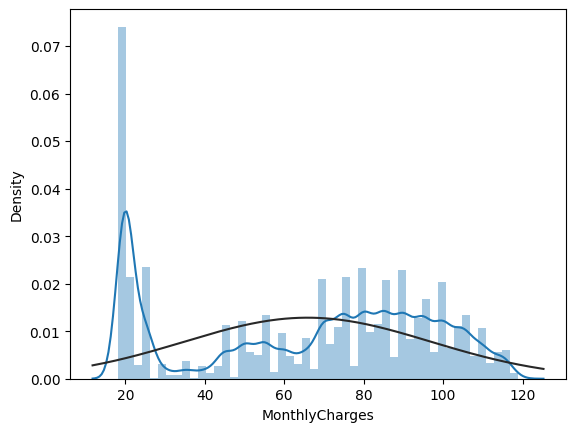

In [43]:
from scipy import stats
from scipy.stats import norm
import seaborn as sns

sns.distplot(train['MonthlyCharges'],fit = norm)

/tmp/ipykernel_55/2986417745.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(train['MonthlyCharges']),fit = norm)


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

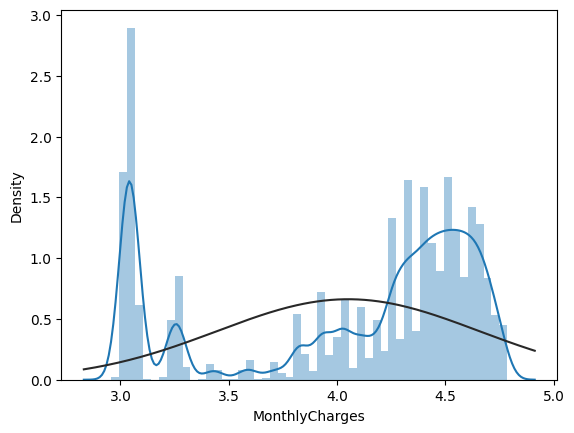

In [44]:
sns.distplot(np.log1p(train['MonthlyCharges']),fit = norm)

In [13]:
# 위의 결과에서 MonthlyCharges가 유효하지 않길래 정규성을 확인한 결과로 
# 기이한 분포가 그려짐. 그래서 np.log1p를 해서도 분포가 이상함.
# MonthlyCharges가 다중공선성 의심이 가지 않는 이유는 다른 독립변수와 크게
# 연관성이 없어보이기 때문임. so, 
# TotalCharges = TotalCharges + MonthlyCharges으로 Feature Engineering
train['TotalCharges'] = train['TotalCharges'] + train['MonthlyCharges']
test['TotalCharges'] = test['TotalCharges'] + test['MonthlyCharges']

In [14]:
logit_model3 = sm.Logit(train['Churn'], train.drop(columns=['MonthlyCharges', 'Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No', 'PaymentMethod_Bank transfer (automatic)','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']))
result3 = logit_model3.fit()
result3.summary()

Optimization terminated successfully.
         Current function value: 0.312331
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594171
Method:                           MLE   Df Model:                           22
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        09:50:52   Log-Likelihood:            -1.8559e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
tenure                                   -0.0720      0.001    -76.424      0.000      -0.074      -0.070
InternetService                           0.9638      0.013     71.784      0.000       0.937       0.990
DeviceProtection                         -0.0360      0.005     -7.150      0.000      -0.046      -0.026
TechSupport                              -0.1133      0.006    -18.950      0.000      -0.125      -0.102
TotalCharges                              0.0003   1.02e-05     33.116      0.000       0.000       0.000
gender_Male                              -0.0167      0.008     -2.045      0.041      -0.033      -0.001
SeniorCitizen_1                           0.4366      0.011     39.951      0.000       0.415       0.458
Partner_Yes                              -0.0231      0.010     -2.253      0.024      -0.043      -0.003
Dependents_Yes                           -0.3259      0.014    -23.964      0.000      -0.353      -0.299
PhoneService_Yes                         -1.2842      0.020    -63.126      0.000      -1.324      -1.244
MultipleLines_No phone service           -0.7167      0.025    -28.636      0.000      -0.766      -0.668
MultipleLines_Yes                         0.3373      0.010     34.950      0.000       0.318       0.356
OnlineSecurity_No internet service       -2.8024      0.035    -81.064      0.000      -2.870      -2.735
OnlineSecurity_Yes                       -0.3705      0.012    -31.128      0.000      -0.394      -0.347
OnlineBackup_Yes                         -0.1017      0.010    -10.413      0.000      -0.121      -0.083
StreamingTV_Yes                           0.3461      0.011     32.907      0.000       0.325       0.367
StreamingMovies_Yes                       0.3190      0.011     30.344      0.000       0.298       0.340
Contract_One year                        -0.7575      0.017    -44.708      0.000      -0.791      -0.724
Contract_Two year                        -1.4230      0.028    -50.407      0.000      -1.478      -1.368
PaperlessBilling_Yes                      0.4099      0.011     36.076      0.000       0.388       0.432
PaymentMethod_Credit card (automatic)    -0.0108      0.018     -0.611      0.541      -0.046       0.024
PaymentMethod_Electronic check            0.6813      0.014     49.060      0.000       0.654       0.709
PaymentMethod_Mailed check               -0.0488      0.019     -2.626      0.009      -0.085      -0.012
=========================================================================================================
"""

In [15]:
# MonthlyCharges를 제외하고 병합된 TotalCharges가 유효한걸 확인.
# PaymentMethod_Credit card (automatic) 컬럼이 유효하지 않은걸 확인..
# PaymentMethod_Credit card (automatic)컬럼을 삭제해서 다른 컬럼에 영향을 
# 미치는지 확인을 했는데 
# PhoneService_Yes, MultipleLines_No phone service과 payment 클래스에 관련된
# 것들이 이상반응을 보임.

In [16]:
logit_model4 = sm.Logit(train['Churn'], train.drop(columns=['MonthlyCharges', 'Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']))
result4 = logit_model4.fit()
result4.summary()

Optimization terminated successfully.
         Current function value: 0.312331
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594171
Method:                           MLE   Df Model:                           22
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        09:51:02   Log-Likelihood:            -1.8559e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
tenure                                     -0.0720      0.001    -76.424      0.000      -0.074      -0.070
InternetService                             0.9638      0.013     71.784      0.000       0.937       0.990
DeviceProtection                           -0.0360      0.005     -7.150      0.000      -0.046      -0.026
TechSupport                                -0.1133      0.006    -18.950      0.000      -0.125      -0.102
TotalCharges                                0.0003   1.02e-05     33.116      0.000       0.000       0.000
gender_Male                                -0.0167      0.008     -2.045      0.041      -0.033      -0.001
SeniorCitizen_1                             0.4366      0.011     39.951      0.000       0.415       0.458
Partner_Yes                                -0.0231      0.010     -2.253      0.024      -0.043      -0.003
Dependents_Yes                             -0.3259      0.014    -23.964      0.000      -0.353      -0.299
PhoneService_Yes                           -0.8471        nan        nan        nan         nan         nan
MultipleLines_No phone service             -0.2796        nan        nan        nan         nan         nan
MultipleLines_Yes                           0.3373      0.010     34.950      0.000       0.318       0.356
OnlineSecurity_No internet service         -2.8024      0.035    -81.064      0.000      -2.870      -2.735
OnlineSecurity_Yes                         -0.3705      0.012    -31.128      0.000      -0.394      -0.347
OnlineBackup_Yes                           -0.1017      0.010    -10.413      0.000      -0.121      -0.083
StreamingTV_Yes                             0.3461      0.011     32.907      0.000       0.325       0.367
StreamingMovies_Yes                         0.3190      0.011     30.344      0.000       0.298       0.340
Contract_One year                          -0.7575      0.017    -44.708      0.000      -0.791      -0.724
Contract_Two year                          -1.4230      0.028    -50.407      0.000      -1.478      -1.368
PaperlessBilling_Yes                        0.4099      0.011     36.076      0.000       0.388       0.432
PaymentMethod_Bank transfer (automatic)    -0.4371        nan        nan        nan         nan         nan
PaymentMethod_Credit card (automatic)      -0.4479        nan        nan        nan         nan         nan
PaymentMethod_Electronic check              0.2442        nan        nan        nan         nan         nan
PaymentMethod_Mailed check                 -0.4859        nan        nan        nan         nan         nan
===========================================================================================================
"""

In [17]:
print(train['PhoneService_Yes'].value_counts())
print(train['MultipleLines_No phone service'].value_counts())
print(train[['PhoneService_Yes', 'MultipleLines_No phone service']])

PhoneService_Yes
1    557893
0     36301
Name: count, dtype: int64
MultipleLines_No phone service
0    557893
1     36301
Name: count, dtype: int64
        PhoneService_Yes  MultipleLines_No phone service
0                      1                               0
1                      1                               0
2                      1                               0
3                      1                               0
4                      1                               0
...                  ...                             ...
594189                 1                               0
594190                 1                               0
594191                 1                               0
594192                 1                               0
594193                 1                               0

[594194 rows x 2 columns]


In [18]:
# PhoneService_Yes와 MultipleLines_No phone service 컬럼은 서로 종속적인 관계
# 따라서 다중공선성 문제가 생기므로 둘중에 하나인 MultipleLines_No phone serivce 삭제.

In [19]:
logit_model5 = sm.Logit(train['Churn'], train.drop(columns=['MultipleLines_No phone service', 'MonthlyCharges', 'Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']))
result5 = logit_model5.fit()
result5.summary()

Optimization terminated successfully.
         Current function value: 0.312331
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594171
Method:                           MLE   Df Model:                           22
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        09:51:10   Log-Likelihood:            -1.8559e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
tenure                                     -0.0720      0.001    -76.424      0.000      -0.074      -0.070
InternetService                             0.9638      0.013     71.784      0.000       0.937       0.990
DeviceProtection                           -0.0360      0.005     -7.150      0.000      -0.046      -0.026
TechSupport                                -0.1133      0.006    -18.950      0.000      -0.125      -0.102
TotalCharges                                0.0003   1.02e-05     33.116      0.000       0.000       0.000
gender_Male                                -0.0167      0.008     -2.045      0.041      -0.033      -0.001
SeniorCitizen_1                             0.4366      0.011     39.951      0.000       0.415       0.458
Partner_Yes                                -0.0231      0.010     -2.253      0.024      -0.043      -0.003
Dependents_Yes                             -0.3259      0.014    -23.964      0.000      -0.353      -0.299
PhoneService_Yes                           -0.5675      0.020    -28.328      0.000      -0.607      -0.528
MultipleLines_Yes                           0.3373      0.010     34.950      0.000       0.318       0.356
OnlineSecurity_No internet service         -2.8024      0.035    -81.064      0.000      -2.870      -2.735
OnlineSecurity_Yes                         -0.3705      0.012    -31.128      0.000      -0.394      -0.347
OnlineBackup_Yes                           -0.1017      0.010    -10.413      0.000      -0.121      -0.083
StreamingTV_Yes                             0.3461      0.011     32.907      0.000       0.325       0.367
StreamingMovies_Yes                         0.3190      0.011     30.344      0.000       0.298       0.340
Contract_One year                          -0.7575      0.017    -44.708      0.000      -0.791      -0.724
Contract_Two year                          -1.4230      0.028    -50.407      0.000      -1.478      -1.368
PaperlessBilling_Yes                        0.4099      0.011     36.076      0.000       0.388       0.432
PaymentMethod_Bank transfer (automatic)    -0.7167      0.025    -28.636      0.000      -0.766      -0.668
PaymentMethod_Credit card (automatic)      -0.7276      0.025    -29.161      0.000      -0.776      -0.679
PaymentMethod_Electronic check             -0.0354      0.022     -1.621      0.105      -0.078       0.007
PaymentMethod_Mailed check                 -0.7655      0.023    -33.302      0.000      -0.811      -0.720
===========================================================================================================
"""

In [20]:
logit_model6 = sm.Logit(train['Churn'], train.drop(columns=['PaymentMethod_Electronic check', 'MultipleLines_No phone service', 'MonthlyCharges', 'Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']))
result6 = logit_model6.fit()
result6.summary()

Optimization terminated successfully.
         Current function value: 0.312333
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594172
Method:                           MLE   Df Model:                           21
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        09:51:14   Log-Likelihood:            -1.8559e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
tenure                                     -0.0726      0.001    -82.975      0.000      -0.074      -0.071
InternetService                             0.9615      0.013     72.021      0.000       0.935       0.988
DeviceProtection                           -0.0368      0.005     -7.327      0.000      -0.047      -0.027
TechSupport                                -0.1143      0.006    -19.248      0.000      -0.126      -0.103
TotalCharges                                0.0003   9.37e-06     36.554      0.000       0.000       0.000
gender_Male                                -0.0192      0.008     -2.403      0.016      -0.035      -0.004
SeniorCitizen_1                             0.4355      0.011     39.926      0.000       0.414       0.457
Partner_Yes                                -0.0236      0.010     -2.300      0.021      -0.044      -0.003
Dependents_Yes                             -0.3272      0.014    -24.104      0.000      -0.354      -0.301
PhoneService_Yes                           -0.5897      0.015    -40.529      0.000      -0.618      -0.561
MultipleLines_Yes                           0.3377      0.010     34.982      0.000       0.319       0.357
OnlineSecurity_No internet service         -2.7965      0.034    -81.365      0.000      -2.864      -2.729
OnlineSecurity_Yes                         -0.3727      0.012    -31.524      0.000      -0.396      -0.350
OnlineBackup_Yes                           -0.1035      0.010    -10.666      0.000      -0.123      -0.084
StreamingTV_Yes                             0.3441      0.010     32.941      0.000       0.324       0.365
StreamingMovies_Yes                         0.3170      0.010     30.365      0.000       0.297       0.337
Contract_One year                          -0.7571      0.017    -44.685      0.000      -0.790      -0.724
Contract_Two year                          -1.4222      0.028    -50.374      0.000      -1.478      -1.367
PaperlessBilling_Yes                        0.4032      0.011     38.156      0.000       0.382       0.424
PaymentMethod_Bank transfer (automatic)    -0.6829      0.014    -49.310      0.000      -0.710      -0.656
PaymentMethod_Credit card (automatic)      -0.6939      0.014    -50.037      0.000      -0.721      -0.667
PaymentMethod_Mailed check                 -0.7362      0.014    -52.021      0.000      -0.764      -0.708
===========================================================================================================
"""

In [21]:
# 마지막으로 PaymentMethod_Electronic check 컬럼의 삭제를 통해 위의 모든 독립변수가 유효한것을 확인
# 지금까지 가장 best인 모델인것으로 확인. 즉, 해당 컬럼들을 선택해서 모델링 구성.

In [62]:
newtrain = train.drop(columns=['PaymentMethod_Electronic check', 'MultipleLines_No phone service', 'MonthlyCharges', 'Churn', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service'])
newtest = test.drop(columns=['PaymentMethod_Electronic check', 'MultipleLines_No phone service', 'MonthlyCharges', 'gender_Female', 'SeniorCitizen_0', 'Partner_No', 'Dependents_No', 'PhoneService_No', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'StreamingTV_No', 'StreamingMovies_No', 'Contract_Month-to-month', 'PaperlessBilling_No','OnlineBackup_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service'])
target = train['Churn']                      

In [63]:
newtrain

,tenure,InternetService,DeviceProtection,TechSupport,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,OnlineSecurity_Yes,OnlineBackup_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Mailed check
0,29,0,2,2,1713.95,1,0,1,1,1,...,1,0,0,0,1,0,1,0,0,1
1,58,0,0,2,3847.70,1,0,1,1,1,...,1,1,1,0,0,1,0,0,1,0
2,58,1,0,0,5941.75,1,0,1,0,1,...,0,1,1,1,0,0,1,0,0,0
3,1,1,0,0,140.40,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,1,1,0,0,140.90,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,57,1,2,0,5558.25,1,0,0,0,1,...,0,0,1,1,0,1,0,1,0,0
594190,72,0,2,2,6874.10,0,0,0,0,1,...,1,1,1,1,0,1,0,1,0,0
594191,72,2,1,1,1896.30,0,0,1,0,1,...,0,0,0,0,0,1,0,0,1,0
594192,32,1,0,0,2933.20,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0


In [64]:
# tenure와 TotalCharges 스케일링!

from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

X_rbst = rs.fit_transform(newtrain[['tenure', 'TotalCharges']])
test_rbst = rs.transform(newtest[['tenure', 'TotalCharges']])

In [81]:
newtrain

,tenure,InternetService,DeviceProtection,TechSupport,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,OnlineSecurity_Yes,OnlineBackup_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Mailed check
0,-0.12,0,2,2,0.063267,1,0,1,1,1,...,1,0,0,0,1,0,1,0,0,1
1,0.46,0,0,2,0.649060,1,0,1,1,1,...,1,1,1,0,0,1,0,0,1,0
2,0.46,1,0,0,1.223953,1,0,1,0,1,...,0,1,1,1,0,0,1,0,0,0
3,-0.68,1,0,0,-0.368730,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,-0.68,1,0,0,-0.368593,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0.44,1,2,0,1.118668,1,0,0,0,1,...,0,0,1,1,0,1,0,1,0,0
594190,0.74,0,2,2,1.479918,0,0,0,0,1,...,1,1,1,1,0,1,0,1,0,0
594191,0.74,2,1,1,0.113329,0,0,1,0,1,...,0,0,0,0,0,1,0,0,1,0
594192,-0.06,1,0,0,0.397996,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0


In [83]:
newtrain['tenure'] = X_rbst[:, 0]
newtrain['TotalCharges'] = X_rbst[:, 1]
newtest['tenure'] = test_rbst[:, 0]
newtest['TotalCharges'] = test_rbst[:, 1]

X_rbst = newtrain.to_numpy()
test_rbst = newtest.to_numpy()

In [85]:
logit_model7 = sm.Logit(target, pd.DataFrame(X_rbst))
result7 = logit_model7.fit()
result7.summary()

Optimization terminated successfully.
         Current function value: 0.319309
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594172
Method:                           MLE   Df Model:                           21
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.4014
Time:                        10:07:15   Log-Likelihood:            -1.8973e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0             -2.1191      0.038    -55.949      0.000      -2.193      -2.045
1              0.9944      0.013     75.080      0.000       0.968       1.020
2             -0.0712      0.005    -14.448      0.000      -0.081      -0.062
3             -0.1648      0.006    -28.145      0.000      -0.176      -0.153
4              0.5082      0.032     16.092      0.000       0.446       0.570
5             -0.1620      0.008    -20.499      0.000      -0.177      -0.147
6              0.3602      0.011     33.332      0.000       0.339       0.381
7             -0.1367      0.010    -13.642      0.000      -0.156      -0.117
8             -0.3984      0.013    -29.629      0.000      -0.425      -0.372
9             -1.4711      0.016    -91.021      0.000      -1.503      -1.439
10             0.3305      0.010     34.510      0.000       0.312       0.349
11            -3.0002      0.034    -86.970      0.000      -3.068      -2.933
12            -0.5161      0.012    -44.442      0.000      -0.539      -0.493
13            -0.2127      0.009    -22.409      0.000      -0.231      -0.194
14             0.2849      0.010     27.587      0.000       0.265       0.305
15             0.2578      0.010     24.985      0.000       0.238       0.278
16            -0.9323      0.016    -56.642      0.000      -0.965      -0.900
17            -1.5495      0.027    -56.438      0.000      -1.603      -1.496
18             0.0461      0.010      4.470      0.000       0.026       0.066
19            -0.8637      0.014    -63.904      0.000      -0.890      -0.837
20            -0.8885      0.014    -65.740      0.000      -0.915      -0.862
21            -0.9992      0.014    -70.762      0.000      -1.027      -0.972
==============================================================================
"""

# Modeling

In [105]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [106]:
random_state = 42
kfold = StratifiedKFold(n_splits=5, shuffle=False)

In [107]:
XGB = XGBClassifier(random_state=random_state)

In [108]:
# XGBoost 파라미터 튜닝 
xgb_param_grid = {'learning_rate': [1,0.1,0.01,0.001],
              'n_estimators': [50, 100, 200, 500, 1000],
              'max_depth' : [1,3,5,10,50]}
gsXGB = GridSearchCV(XGB,param_grid = xgb_param_grid, cv=kfold, scoring="accuracy", n_jobs= 4, verbose = 1)
gsXGB.fit(X_rbst, target)
XGB_best = gsXGB.best_estimator_

# 최고 점수
gsXGB.best_score_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


np.float64(0.8608787679516794)

In [114]:
import joblib

joblib.dump(XGB_best, "xgb_model.pkl")


['xgb_model.pkl']

In [111]:
Prediction = XGB_best.predict(test_rbst)

In [112]:
submission = pd.DataFrame({
    "id": id,
    "Churn": Prediction
})

submission.to_csv("submission.csv", index=False)

In [113]:
submission

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,1
...,...,...
254650,848844,0
254651,848845,1
254652,848846,0
254653,848847,0
